In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Check versions to confirm install worked
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("All libraries imported successfully ✅")

pandas: 2.3.3
numpy: 2.3.5
All libraries imported successfully ✅


In [2]:
import pandas as pd
import numpy as np
import random

np.random.seed(42)
random.seed(42)

# ---- Reference lists to build realistic data ----
restaurant_names = [
    "Spice Garden", "Tandoori Nights", "The Curry Leaf", "Pizza Bella", "Sushi Zen",
    "Burger Barn", "Cafe Mocha", "Royal Biryani House", "Noodle Street", "Taco Fiesta",
    "Green Bowl", "The Bread Basket", "Punjabi Dhaba", "Wok This Way", "Cheesecake Factory Lite",
    "Coastal Catch", "Urban Tadka", "Mughlai Mahal", "Pasta Pronto", "BBQ Pit Stop",
    "Sweet Tooth", "South Spice", "The Coffee House", "Momo Magic", "Kebab Junction",
    "Brew & Bite", "Grill Master", "Dim Sum Den", "Falafel King", "Pancake Paradise"
]

cities = ["Mumbai", "Delhi", "Bangalore", "Pune", "Hyderabad", "Chennai", "Kolkata", "Jaipur"]

locations_by_city = {
    "Mumbai": ["Andheri", "Bandra", "Powai", "Dadar"],
    "Delhi": ["Connaught Place", "Saket", "Karol Bagh", "Dwarka"],
    "Bangalore": ["Indiranagar", "Koramangala", "Whitefield", "Jayanagar"],
    "Pune": ["Koregaon Park", "Viman Nagar", "Hinjewadi", "Kothrud"],
    "Hyderabad": ["Banjara Hills", "Gachibowli", "Jubilee Hills", "Madhapur"],
    "Chennai": ["T Nagar", "Adyar", "Anna Nagar", "Velachery"],
    "Kolkata": ["Park Street", "Salt Lake", "Ballygunge", "Howrah"],
    "Jaipur": ["Malviya Nagar", "C Scheme", "Vaishali Nagar", "Tonk Road"]
}

cuisines_list = [
    "North Indian", "South Indian", "Chinese", "Italian", "Mexican",
    "Fast Food", "Continental", "Bakery", "Cafe", "Desserts",
    "Mughlai", "Thai", "Japanese", "Street Food", "BBQ"
]

n = 500  # number of restaurants

data = []
for i in range(1, n + 1):
    city = random.choice(cities)
    location = random.choice(locations_by_city[city])
    name = random.choice(restaurant_names) + f" - {location}"  # avoid duplicate name conflicts
    cuisine = ", ".join(random.sample(cuisines_list, k=random.randint(1, 3)))
    
    online_order = random.choice(["Yes", "No"])
    table_booking = random.choice(["Yes", "No"])
    
    rating = round(np.random.uniform(2.5, 4.9), 1)
    votes = int(np.random.exponential(scale=300))  # most have few votes, some go viral
    
    cost_for_two = random.choice([200, 300, 400, 500, 600, 800, 1000, 1200, 1500, 2000])
    
    data.append({
        "restaurant_id": 1000 + i,
        "name": name,
        "city": city,
        "location": location,
        "cuisines": cuisine,
        "rating": rating,
        "votes": votes,
        "online_order": online_order,
        "table_booking": table_booking,
        "cost_for_two": cost_for_two
    })

df = pd.DataFrame(data)

# ---- Inject some realistic messiness for the cleaning step later ----
# Some missing ratings
missing_idx = np.random.choice(df.index, size=15, replace=False)
df.loc[missing_idx, "rating"] = np.nan

# Some missing cuisines
missing_idx2 = np.random.choice(df.index, size=10, replace=False)
df.loc[missing_idx2, "cuisines"] = np.nan

# Some duplicate rows
df = pd.concat([df, df.sample(5, random_state=1)], ignore_index=True)

# Inconsistent text casing (real-world mess)
df.loc[df.sample(20, random_state=2).index, "online_order"] = df["online_order"].str.upper()

# Save to CSV
df.to_csv("zomato.csv", index=False)

print("Dataset created successfully ✅")
print("Shape:", df.shape)
df.head()

Dataset created successfully ✅
Shape: (505, 10)


,restaurant_id,name,city,location,cuisines,rating,votes,online_order,table_booking,cost_for_two
0,1001,Momo Magic - Connaught Place,Delhi,Connaught Place,"Italian, BBQ",3.4,903,Yes,Yes,1500
1,1002,Tandoori Nights - Dwarka,Delhi,Dwarka,South Indian,4.3,273,YES,Yes,1500
2,1003,The Coffee House - Bandra,Mumbai,Bandra,"Thai, Cafe, Continental",2.9,50,Yes,No,2000
3,1004,Kebab Junction - Banjara Hills,Hyderabad,Banjara Hills,Thai,2.6,603,No,No,600
4,1005,Kebab Junction - Koramangala,Bangalore,Koramangala,"South Indian, BBQ",3.9,369,No,Yes,800


In [3]:
# Check data types and missing values
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   restaurant_id  505 non-null    int64  
 1   name           505 non-null    object 
 2   city           505 non-null    object 
 3   location       505 non-null    object 
 4   cuisines       495 non-null    object 
 5   rating         489 non-null    float64
 6   votes          505 non-null    int64  
 7   online_order   505 non-null    object 
 8   table_booking  505 non-null    object 
 9   cost_for_two   505 non-null    int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 39.6+ KB
None

Missing values per column:
restaurant_id     0
name              0
city              0
location          0
cuisines         10
rating           16
votes             0
online_order      0
table_booking     0
cost_for_two      0
dtype: int64

Duplicate rows: 4


In [4]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (501, 10)


In [5]:
df["online_order"] = df["online_order"].str.strip().str.capitalize()
df["table_booking"] = df["table_booking"].str.strip().str.capitalize()

print(df["online_order"].unique())
print(df["table_booking"].unique())

['Yes' 'No']
['Yes' 'No']


In [6]:
df["cuisines"] = df["cuisines"].fillna("Not Specified")
print(df["cuisines"].isnull().sum())  # should be 0

0


In [7]:
median_rating = df["rating"].median()
df["rating"] = df["rating"].fillna(median_rating)

print("Median rating used:", median_rating)
print("Missing ratings remaining:", df["rating"].isnull().sum())  # should be 0

Median rating used: 3.6
Missing ratings remaining: 0


In [8]:
def rating_category(r):
    if r >= 4.0:
        return "Excellent"
    elif r >= 3.0:
        return "Good"
    else:
        return "Average"

df["rating_category"] = df["rating"].apply(rating_category)
df["rating_category"].value_counts()

rating_category
Good         200
Excellent    182
Average      119
Name: count, dtype: int64

In [9]:
print("Final shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
df.head()

Final shape: (501, 11)

Missing values:
 restaurant_id      0
name               0
city               0
location           0
cuisines           0
rating             0
votes              0
online_order       0
table_booking      0
cost_for_two       0
rating_category    0
dtype: int64

Data types:
 restaurant_id        int64
name                object
city                object
location            object
cuisines            object
rating             float64
votes                int64
online_order        object
table_booking       object
cost_for_two         int64
rating_category     object
dtype: object


,restaurant_id,name,city,location,cuisines,rating,votes,online_order,table_booking,cost_for_two,rating_category
0,1001,Momo Magic - Connaught Place,Delhi,Connaught Place,"Italian, BBQ",3.4,903,Yes,Yes,1500,Good
1,1002,Tandoori Nights - Dwarka,Delhi,Dwarka,South Indian,4.3,273,Yes,Yes,1500,Excellent
2,1003,The Coffee House - Bandra,Mumbai,Bandra,"Thai, Cafe, Continental",2.9,50,Yes,No,2000,Average
3,1004,Kebab Junction - Banjara Hills,Hyderabad,Banjara Hills,Thai,2.6,603,No,No,600,Average
4,1005,Kebab Junction - Koramangala,Bangalore,Koramangala,"South Indian, BBQ",3.9,369,No,Yes,800,Good


In [10]:
df.describe()

,restaurant_id,rating,votes,cost_for_two
count,501.000000,501.000000,501.000000,501.000000
mean,1250.135729,3.635729,308.838323,827.544910
std,144.567388,0.704997,302.289093,547.539734
min,1001.000000,2.500000,1.000000,200.000000
25%,1125.000000,3.000000,93.000000,400.000000
50%,1250.000000,3.600000,222.000000,600.000000
75%,1375.000000,4.200000,425.000000,1200.000000
max,1500.000000,4.900000,2451.000000,2000.000000


city
Jaipur       67
Chennai      66
Hyderabad    64
Pune         64
Kolkata      63
Delhi        62
Bangalore    61
Mumbai       54
Name: count, dtype: int64


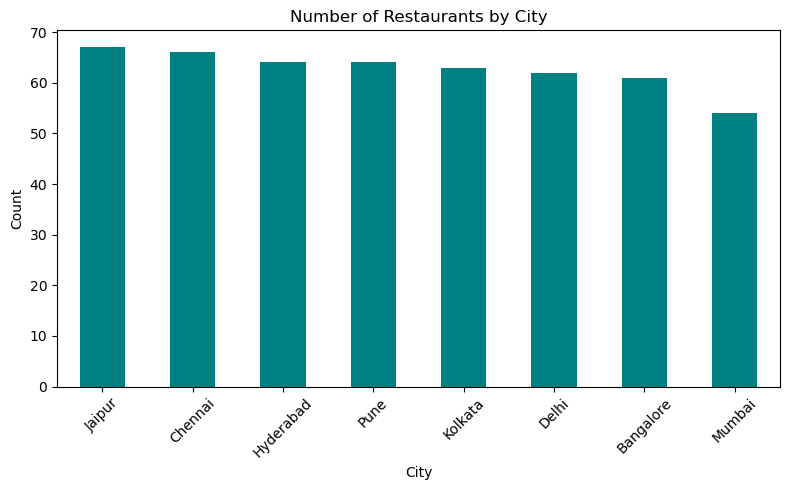

In [11]:
city_counts = df["city"].value_counts()
print(city_counts)

city_counts.plot(kind="bar", figsize=(8,5), color="teal")
plt.title("Number of Restaurants by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bakery          78
South Indian    77
Continental     76
Fast Food       76
Mexican         75
Thai            69
Japanese        69
Cafe            66
North Indian    64
BBQ             62
dtype: int64


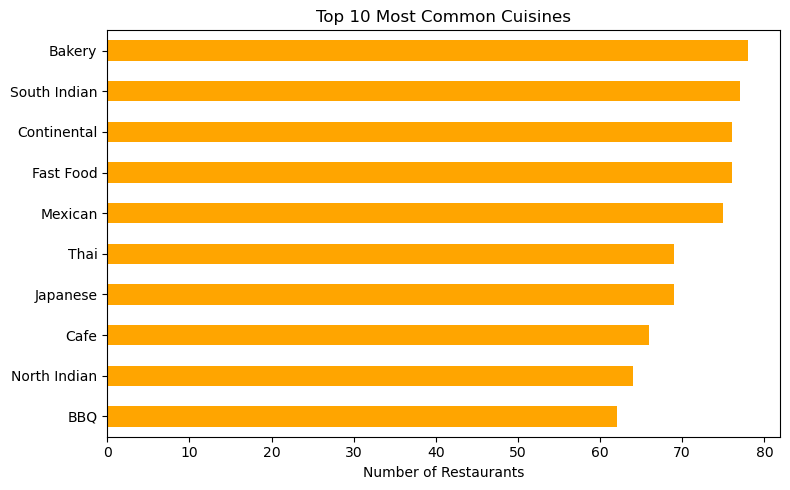

In [12]:
from collections import Counter

all_cuisines = df["cuisines"].str.split(", ").explode()
cuisine_counts = Counter(all_cuisines)

top_cuisines = pd.Series(cuisine_counts).sort_values(ascending=False).head(10)
print(top_cuisines)

top_cuisines.plot(kind="barh", figsize=(8,5), color="orange")
plt.title("Top 10 Most Common Cuisines")
plt.xlabel("Number of Restaurants")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

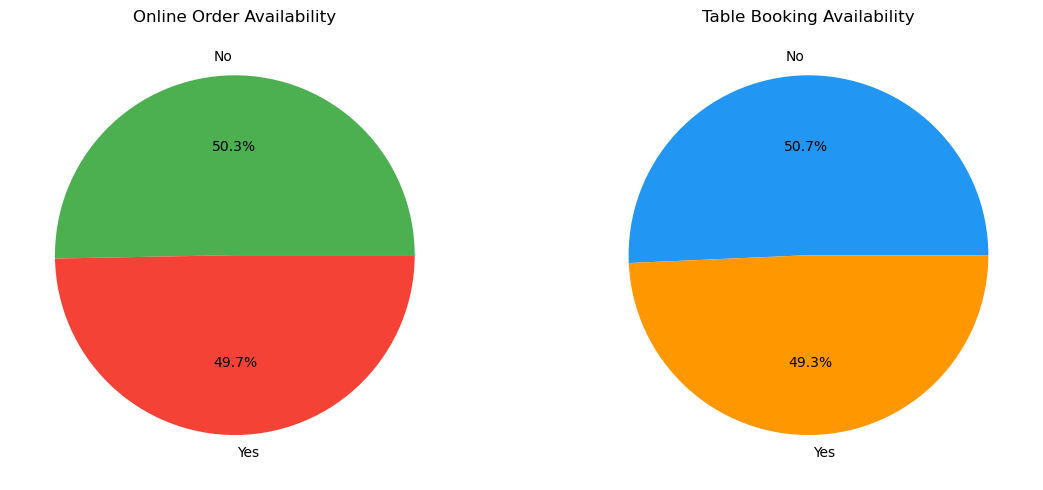

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

df["online_order"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=axes[0], colors=["#4CAF50","#F44336"])
axes[0].set_title("Online Order Availability")
axes[0].set_ylabel("")

df["table_booking"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=axes[1], colors=["#2196F3","#FF9800"])
axes[1].set_title("Table Booking Availability")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

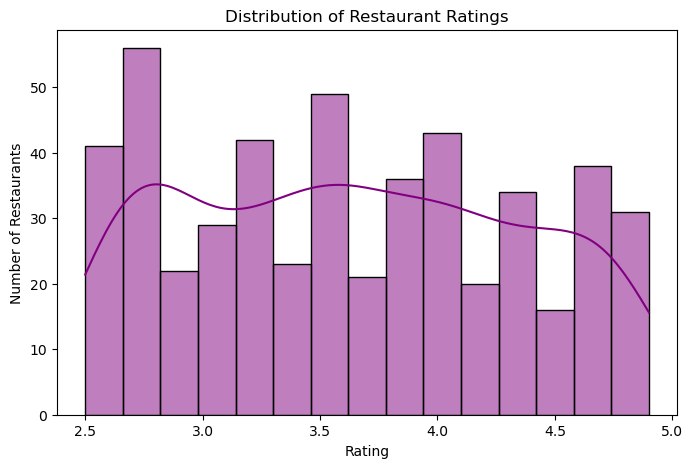

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["rating"], bins=15, kde=True, color="purple")
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()

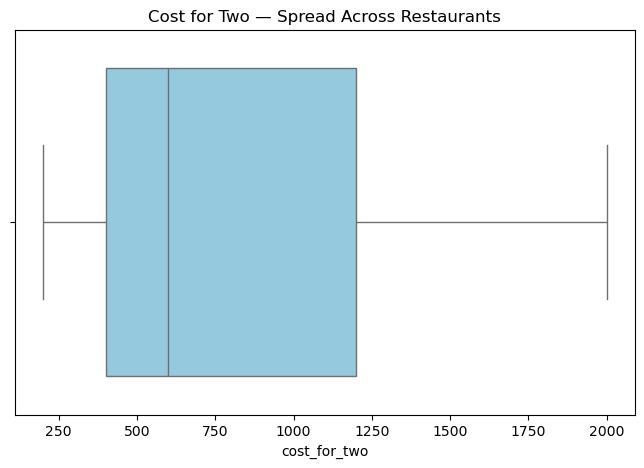

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["cost_for_two"], color="skyblue")
plt.title("Cost for Two — Spread Across Restaurants")
plt.show()

In [16]:
most_voted = df.loc[df["votes"].idxmax()]
print("Most Voted Restaurant:")
print(most_voted[["name", "city", "votes", "rating", "cuisines"]])

Most Voted Restaurant:
name        The Coffee House - Velachery
city                             Chennai
votes                               2451
rating                               4.5
cuisines           BBQ, Bakery, Japanese
Name: 265, dtype: object


In [17]:
most_voted = df.loc[df["votes"].idxmax()]
print("Most Voted Restaurant:")
print(most_voted[["name", "city", "votes", "rating", "cuisines"]])

Most Voted Restaurant:
name        The Coffee House - Velachery
city                             Chennai
votes                               2451
rating                               4.5
cuisines           BBQ, Bakery, Japanese
Name: 265, dtype: object


In [18]:
top10_voted = df.sort_values(by="votes", ascending=False).head(10)
top10_voted[["name", "city", "votes", "rating"]]

,name,city,votes,rating
265,The Coffee House - Velachery,Chennai,2451,4.5
423,Cafe Mocha - Adyar,Chennai,1730,2.7
237,The Bread Basket - Dwarka,Delhi,1487,3.8
130,Cafe Mocha - Salt Lake,Kolkata,1383,4.0
352,Brew & Bite - T Nagar,Chennai,1380,2.7
34,Falafel King - Park Street,Kolkata,1300,3.6
220,Cheesecake Factory Lite - T Nagar,Chennai,1294,2.7
330,Sweet Tooth - Powai,Mumbai,1291,3.4
249,Grill Master - Howrah,Kolkata,1285,4.8
337,Pizza Bella - Hinjewadi,Pune,1211,3.5


C:\Users\Clevina\AppData\Local\Temp\ipykernel_7052\3892135773.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


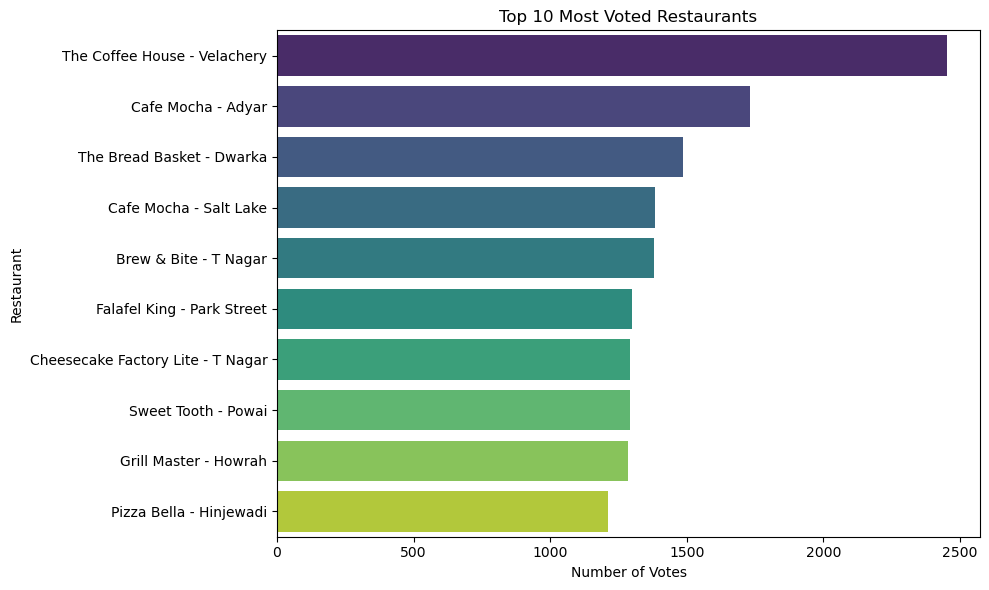

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=top10_voted,
    x="votes",
    y="name",
    palette="viridis"
)
plt.title("Top 10 Most Voted Restaurants")
plt.xlabel("Number of Votes")
plt.ylabel("Restaurant")
plt.tight_layout()
plt.show()

In [20]:
most_voted_per_city = df.loc[df.groupby("city")["votes"].idxmax()]
most_voted_per_city[["city", "name", "votes", "rating"]].sort_values(by="votes", ascending=False)


,city,name,votes,rating
265,Chennai,The Coffee House - Velachery,2451,4.5
237,Delhi,The Bread Basket - Dwarka,1487,3.8
130,Kolkata,Cafe Mocha - Salt Lake,1383,4.0
330,Mumbai,Sweet Tooth - Powai,1291,3.4
337,Pune,Pizza Bella - Hinjewadi,1211,3.5
287,Jaipur,The Coffee House - C Scheme,895,4.6
16,Hyderabad,Burger Barn - Madhapur,892,2.7
222,Bangalore,Green Bowl - Koramangala,882,4.5


In [21]:
online_counts = df["online_order"].value_counts()
online_pct = df["online_order"].value_counts(normalize=True) * 100

print("Counts:\n", online_counts)
print("\nPercentage:\n", online_pct.round(1))

Counts:
 online_order
No     252
Yes    249
Name: count, dtype: int64

Percentage:
 online_order
No     50.3
Yes    49.7
Name: proportion, dtype: float64


online_order
No     3.63
Yes    3.64
Name: rating, dtype: float64


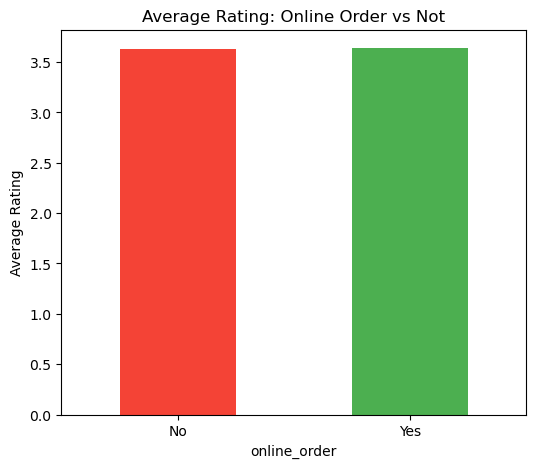

In [22]:
avg_rating_by_order = df.groupby("online_order")["rating"].mean().round(2)
print(avg_rating_by_order)

avg_rating_by_order.plot(kind="bar", color=["#F44336","#4CAF50"], figsize=(6,5))
plt.title("Average Rating: Online Order vs Not")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.show()

online_order
No     293.0
Yes    325.0
Name: votes, dtype: float64


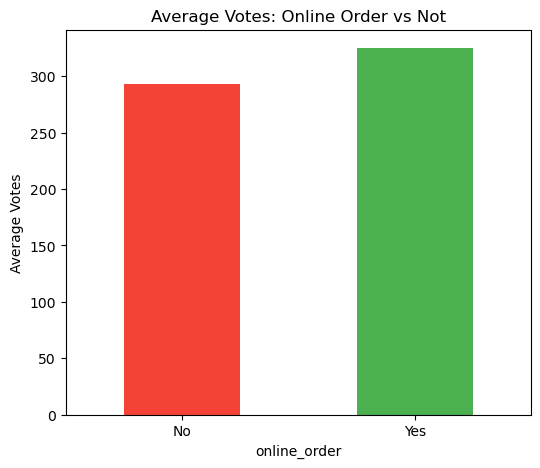

In [23]:
avg_votes_by_order = df.groupby("online_order")["votes"].mean().round(0)
print(avg_votes_by_order)

avg_votes_by_order.plot(kind="bar", color=["#F44336","#4CAF50"], figsize=(6,5))
plt.title("Average Votes: Online Order vs Not")
plt.ylabel("Average Votes")
plt.xticks(rotation=0)
plt.show()

online_order
No     833.0
Yes    822.0
Name: cost_for_two, dtype: float64


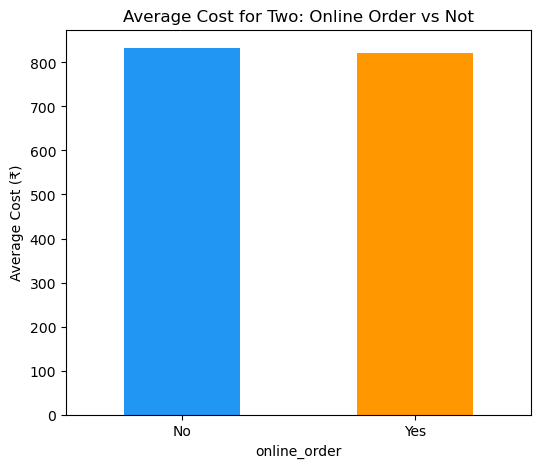

In [24]:
avg_cost_by_order = df.groupby("online_order")["cost_for_two"].mean().round(0)
print(avg_cost_by_order)

avg_cost_by_order.plot(kind="bar", color=["#2196F3","#FF9800"], figsize=(6,5))
plt.title("Average Cost for Two: Online Order vs Not")
plt.ylabel("Average Cost (₹)")
plt.xticks(rotation=0)
plt.show()

online_order    No   Yes
city                    
Bangalore     47.5  52.5
Chennai       62.1  37.9
Delhi         46.8  53.2
Hyderabad     53.1  46.9
Jaipur        41.8  58.2
Kolkata       54.0  46.0
Mumbai        55.6  44.4
Pune          42.2  57.8


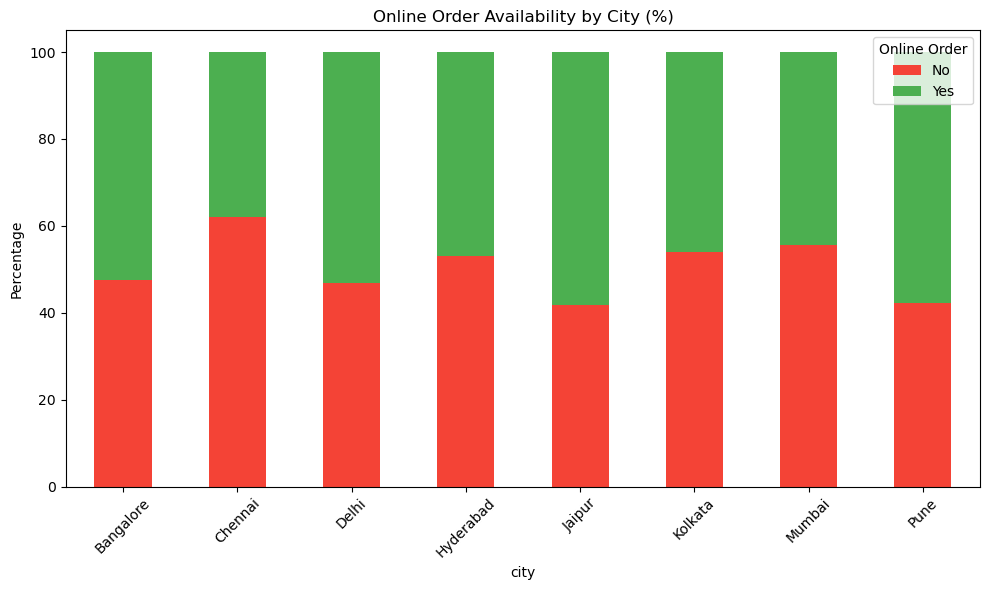

In [25]:
order_by_city = pd.crosstab(df["city"], df["online_order"], normalize="index") * 100
order_by_city = order_by_city.round(1)
print(order_by_city)

order_by_city.plot(kind="bar", stacked=True, figsize=(10,6), color=["#F44336","#4CAF50"])
plt.title("Online Order Availability by City (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Online Order")
plt.tight_layout()
plt.show()

city
Pune         3.79
Kolkata      3.68
Delhi        3.67
Jaipur       3.65
Hyderabad    3.65
Mumbai       3.61
Bangalore    3.58
Chennai      3.45
Name: rating, dtype: float64


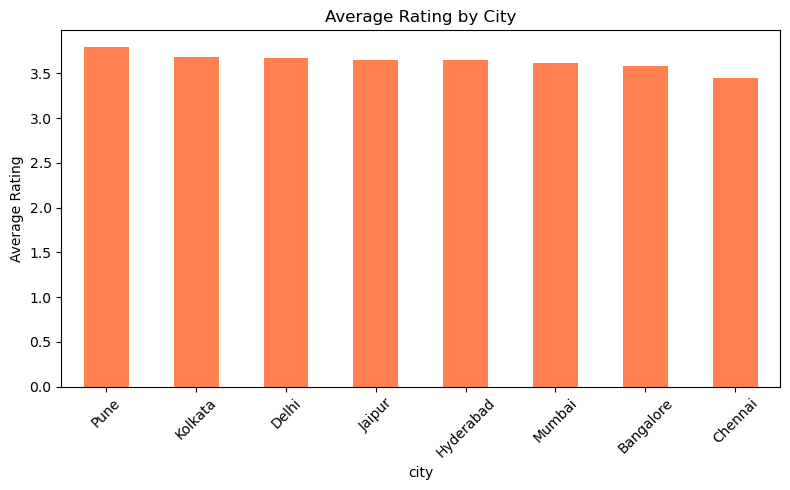

In [26]:
avg_rating_city = df.groupby("city")["rating"].mean().sort_values(ascending=False).round(2)
print(avg_rating_city)

avg_rating_city.plot(kind="bar", figsize=(8,5), color="coral")
plt.title("Average Rating by City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

rating_category
Good         200
Excellent    182
Average      119
Name: count, dtype: int64


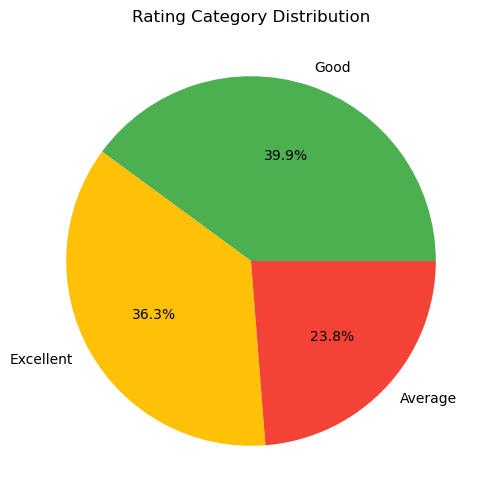

In [27]:
rating_cat_counts = df["rating_category"].value_counts()
print(rating_cat_counts)

rating_cat_counts.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6),
                        colors=["#4CAF50","#FFC107","#F44336"])
plt.title("Rating Category Distribution")
plt.ylabel("")
plt.show()

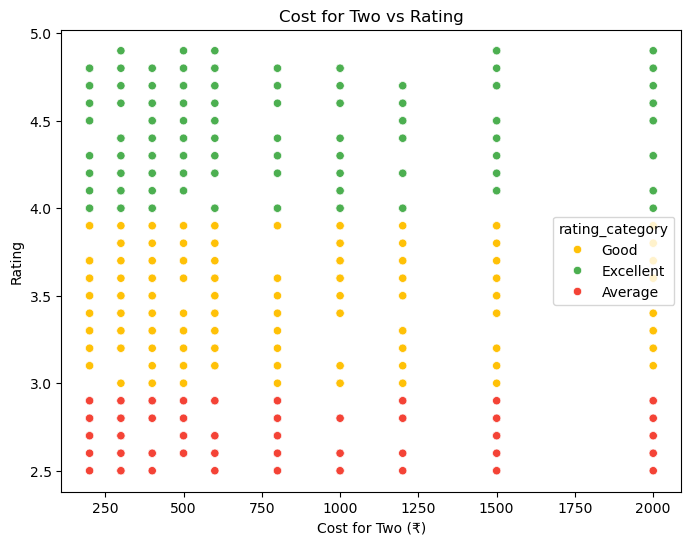

In [28]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="cost_for_two", y="rating", hue="rating_category",
                 palette={"Excellent":"#4CAF50","Good":"#FFC107","Average":"#F44336"})
plt.title("Cost for Two vs Rating")
plt.xlabel("Cost for Two (₹)")
plt.ylabel("Rating")
plt.show()

C:\Users\Clevina\AppData\Local\Temp\ipykernel_7052\2874376387.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="online_order", y="rating", ax=axes[0], palette=["#F44336","#4CAF50"])
C:\Users\Clevina\AppData\Local\Temp\ipykernel_7052\2874376387.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="table_booking", y="rating", ax=axes[1], palette=["#2196F3","#FF9800"])


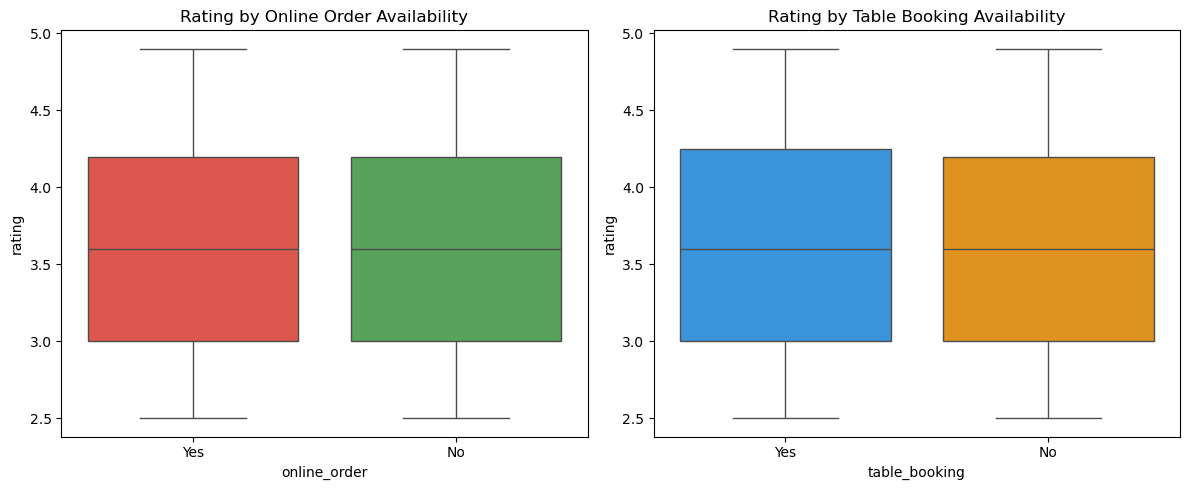

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(data=df, x="online_order", y="rating", ax=axes[0], palette=["#F44336","#4CAF50"])
axes[0].set_title("Rating by Online Order Availability")

sns.boxplot(data=df, x="table_booking", y="rating", ax=axes[1], palette=["#2196F3","#FF9800"])
axes[1].set_title("Rating by Table Booking Availability")

plt.tight_layout()
plt.show()

               mean  count
cuisines                  
Italian        3.82     56
Mexican        3.77     75
Japanese       3.76     69
Not Specified  3.74     10
Cafe           3.72     66
Fast Food      3.71     76
Continental    3.69     76
Street Food    3.69     56
South Indian   3.67     77
Mughlai        3.66     61


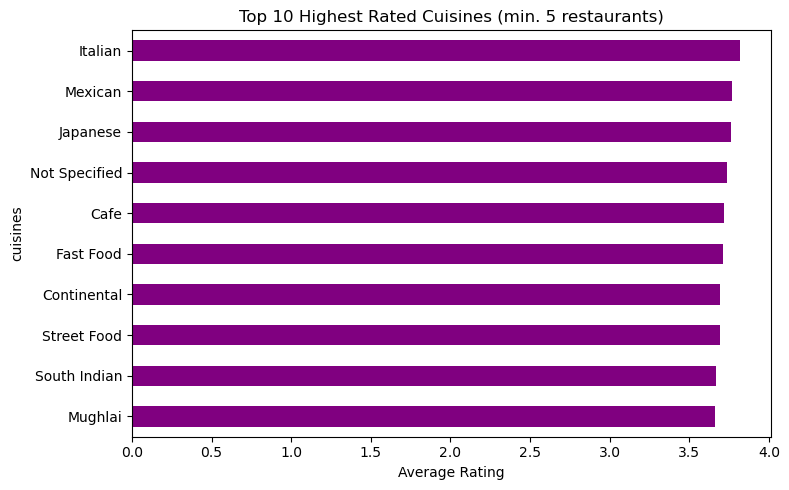

In [30]:
cuisine_exploded = df.assign(cuisines=df["cuisines"].str.split(", ")).explode("cuisines")

cuisine_rating = cuisine_exploded.groupby("cuisines")["rating"].agg(["mean","count"])
cuisine_rating = cuisine_rating[cuisine_rating["count"] >= 5].sort_values(by="mean", ascending=False)
cuisine_rating["mean"] = cuisine_rating["mean"].round(2)

print(cuisine_rating.head(10))

cuisine_rating.head(10)["mean"].plot(kind="barh", figsize=(8,5), color="purple")
plt.title("Top 10 Highest Rated Cuisines (min. 5 restaurants)")
plt.xlabel("Average Rating")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

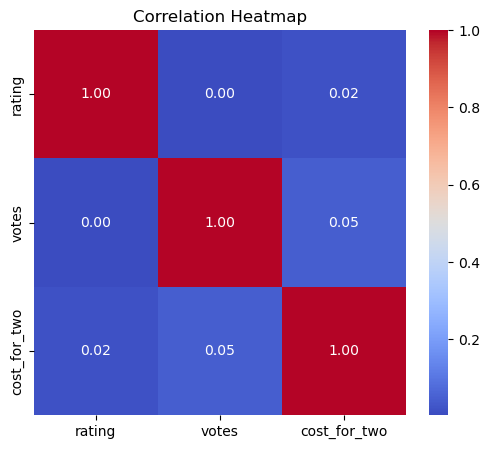

In [31]:
plt.figure(figsize=(6,5))
corr = df[["rating","votes","cost_for_two"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [32]:
df.to_csv("zomato_cleaned.csv", index=False)
print("Cleaned dataset saved as zomato_cleaned.csv")

Cleaned dataset saved as zomato_cleaned.csv


In [33]:
findings = f"""
ZOMATO RESTAURANT DATA ANALYSIS — KEY FINDINGS
================================================

Dataset Overview:
- Total restaurants analyzed: {df.shape[0]}
- Cities covered: {df['city'].nunique()}

Most Voted Restaurant:
- {most_voted['name']} ({most_voted['city']}) — {int(most_voted['votes'])} votes, rating {most_voted['rating']}

Online Order Availability:
- {online_pct['Yes']:.1f}% of restaurants offer online ordering

Ratings:
- Average rating overall: {df['rating'].mean():.2f}
- City with highest average rating: {avg_rating_city.idxmax()} ({avg_rating_city.max():.2f})
- Top rated cuisine (min. 5 restaurants): {cuisine_rating.index[0]} ({cuisine_rating['mean'].iloc[0]})

Cost:
- Average cost for two: ₹{df['cost_for_two'].mean():.0f}
"""

print(findings)

with open("key_findings.txt", "w") as f:
    f.write(findings)

print("Saved as key_findings.txt")


ZOMATO RESTAURANT DATA ANALYSIS — KEY FINDINGS

Dataset Overview:
- Total restaurants analyzed: 501
- Cities covered: 8

Most Voted Restaurant:
- The Coffee House - Velachery (Chennai) — 2451 votes, rating 4.5

Online Order Availability:
- 49.7% of restaurants offer online ordering

Ratings:
- Average rating overall: 3.64
- City with highest average rating: Pune (3.79)
- Top rated cuisine (min. 5 restaurants): Italian (3.82)

Cost:
- Average cost for two: ₹828



UnicodeEncodeError: 'charmap' codec can't encode character '\u20b9' in position 530: character maps to <undefined>

In [34]:
print(df.shape)
df.head()

(501, 11)


,restaurant_id,name,city,location,cuisines,rating,votes,online_order,table_booking,cost_for_two,rating_category
0,1001,Momo Magic - Connaught Place,Delhi,Connaught Place,"Italian, BBQ",3.4,903,Yes,Yes,1500,Good
1,1002,Tandoori Nights - Dwarka,Delhi,Dwarka,South Indian,4.3,273,Yes,Yes,1500,Excellent
2,1003,The Coffee House - Bandra,Mumbai,Bandra,"Thai, Cafe, Continental",2.9,50,Yes,No,2000,Average
3,1004,Kebab Junction - Banjara Hills,Hyderabad,Banjara Hills,Thai,2.6,603,No,No,600,Average
4,1005,Kebab Junction - Koramangala,Bangalore,Koramangala,"South Indian, BBQ",3.9,369,No,Yes,800,Good


In [36]:
findings = f"""
ZOMATO RESTAURANT DATA ANALYSIS — KEY FINDINGS
================================================

Dataset Overview:
- Total restaurants analyzed: {df.shape[0]}
- Cities covered: {df['city'].nunique()}

Most Voted Restaurant:
- {most_voted['name']} ({most_voted['city']}) — {int(most_voted['votes'])} votes, rating {most_voted['rating']}

Online Order Availability:
- {online_pct['Yes']:.1f}% of restaurants offer online ordering

Ratings:
- Average rating overall: {df['rating'].mean():.2f}
- City with highest average rating: {avg_rating_city.idxmax()} ({avg_rating_city.max():.2f})
- Top rated cuisine (min. 5 restaurants): {cuisine_rating.index[0]} ({cuisine_rating['mean'].iloc[0]})

Cost:
- Average cost for two: ₹{df['cost_for_two'].mean():.0f}
"""

print(findings)

with open("key_findings.txt", "w", encoding="utf-8") as f:
    f.write(findings)

print("Saved as key_findings.txt")


ZOMATO RESTAURANT DATA ANALYSIS — KEY FINDINGS

Dataset Overview:
- Total restaurants analyzed: 501
- Cities covered: 8

Most Voted Restaurant:
- The Coffee House - Velachery (Chennai) — 2451 votes, rating 4.5

Online Order Availability:
- 49.7% of restaurants offer online ordering

Ratings:
- Average rating overall: 3.64
- City with highest average rating: Pune (3.79)
- Top rated cuisine (min. 5 restaurants): Italian (3.82)

Cost:
- Average cost for two: ₹828

Saved as key_findings.txt


In [37]:
requirements = """pandas
numpy
matplotlib
seaborn
plotly
jupyter
notebook
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created")

requirements.txt created


In [4]:
requirements = """pandas
numpy
matplotlib
seaborn
plotly
jupyter
notebook
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created")

requirements.txt created


In [5]:
gitignore_content = """venv/
__pycache__/
.ipynb_checkpoints/
*.pyc
"""

with open(".gitignore", "w", encoding="utf-8") as f:
    f.write(gitignore_content)

print(".gitignore created")

.gitignore created


In [17]:
readme_content = """# Zomato Restaurant Data Analysis 🍽️

A data analysis and visualization project exploring restaurant trends — ratings, votes, online ordering, and cost — using Python.

## 📊 Project Overview
This project analyzes a restaurant dataset to uncover insights such as:
- Most voted restaurants
- Online order & table booking availability trends
- Rating distributions and comparisons across cities and cuisines
- Relationship between cost, votes, and ratings

## 🛠️ Tools & Libraries
- Python
- pandas, numpy
- matplotlib, seaborn, plotly
- Jupyter Notebook

## 📁 Project Structure
- data/
- notebook.ipynb
- README.md
"""

In [18]:
print(readme_content)

# Zomato Restaurant Data Analysis 🍽️

A data analysis and visualization project exploring restaurant trends — ratings, votes, online ordering, and cost — using Python.

## 📊 Project Overview
This project analyzes a restaurant dataset to uncover insights such as:
- Most voted restaurants
- Online order & table booking availability trends
- Rating distributions and comparisons across cities and cuisines
- Relationship between cost, votes, and ratings

## 🛠️ Tools & Libraries
- Python
- pandas, numpy
- matplotlib, seaborn, plotly
- Jupyter Notebook

## 📁 Project Structure
- data/
- notebook.ipynb
- README.md



In [22]:
with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [23]:
import os
print(os.listdir())

['.gitignore', '.ipynb_checkpoints', 'jupyter_notebook_config.d', 'jupyter_server_config.d', 'key_findings.txt', 'nbconfig', 'README.md', 'requirements.txt', 'zomato.csv', 'zomato_analysis.ipynb', 'zomato_cleaned.csv']


In [24]:
import os
print(os.getcwd())

C:\Users\Clevina\zomato-data-analysis\venv\etc\jupyter
